In [1]:
import numpy as np
import pandas as pd
import multiprocessing
import math
import pickle as pk
from tqdm import tqdm
from pathlib import Path
from sklearn.decomposition import PCA

# import os
# import sys
# sys.path.append(os.path.abspath('..'))
from neutrophil_shape.config.loader import load_config
from neutrophil_shape.CustomFunctions import shtools_mod, shapePCAtools, file_management



In [2]:

### load config stuff
config = load_config(microscope_type = 'confocal')
#set alignment
config._alignment = 'trajectory'
basedir = config.common.basedir
datadir = config.common.savedir / 'shape_data'
pcmeshdir = datadir / 'PC_Meshes'

In [3]:
############# gather data from all experiments ###############
# get the datasets to be combined
datasets = list(datadir.glob('Shape_Metrics*'))
smdf = pd.concat([pd.read_csv(d, index_col=0) for d in datasets], ignore_index = True)

### get all processed data directories
foldlist = [ex.localdir for e, ex in vars(config.experiment).items() if e != 'lls']

#open all of the other metrics from the single csv files
if __name__ == '__main__':
    with multiprocessing.Pool(processes=60) as pool:
        csvlist = [f.joinpath('smooth_traj').glob('*_cell_info.csv') for f in foldlist]
        csvlist = [item for sublist in csvlist for item in sublist]
        celllist = list(tqdm(pool.imap(file_management.multicsv, csvlist), total=len(csvlist)))
cellinfo = pd.concat(celllist, ignore_index = True)

### make dataframes and merge    
combineddata = smdf.merge(cellinfo.drop(columns=['image']), on = 'cell', how = 'left')
## drop the bad SH
combineddata = combineddata[combineddata.centroid_inside].copy()

100%|██████████| 157656/157656 [03:03<00:00, 858.49it/s] 


In [4]:
########### DATA MANAGEMENT AND FILTERING ###############
#start by sorting
df = combineddata.copy().sort_values(['CellID','frame']).reset_index(drop=True)
print(len(df))

############# add some identifiers ############
treat = []
experiment = []
date = []
galv37Cdates = ['20231116', '20231122']

for f, m in zip(df['cell'].to_list(), df['frame'].to_list()):
    if 'CK666' in f:
        treat.append('CK666')
        experiment.append('Drug')
    elif 'ParaNitroBleb' in f:
        treat.append('Para-Nitro-Blebbistatin')
        experiment.append('Drug')
    elif 'DMSO' in f:
        treat.append('DMSO')
        experiment.append('Drug')
    elif any([x in f for x in galv37Cdates]) and m<181:
        treat.append('Random')
        experiment.append('Galvanotaxis')
    elif any([x in f for x in galv37Cdates]) and m<=185:
        treat.append('Pre-Galvanotaxis')
        experiment.append('Galvanotaxis')
    elif any([x in f for x in galv37Cdates]) and m>185:
        treat.append('Galvanotaxis')
        experiment.append('Galvanotaxis')
    else:
        print(f'Hey this one isnt captured: {f}')

    #get the date and experiment number on that date
    spl = f.split('_')
    date.append(spl[0])

df['Date'] = date
df['Treatment'] = treat
df['Experiment'] = experiment


############# filter out absolute shape outliers #############
df = df[(df.Cell_Volume < 1550) & (df.Cell_Volume > 498)]
df = df[(df.Cell_SurfaceArea < 1800) & (df.Cell_SurfaceArea > 500)]
df.reset_index(drop=True, inplace=True)
print(len(df))

########### filter out jumps in speed or volume that 
########### may reflect poor segmentation and affect
########### trajectory/alignment
#volume differences
big_vol_diffs = df[df.Cell_Volume.pct_change().abs()>0.3].index.to_list()
#transitions between cells
cell_shifts = df[df.CellID != df.CellID.shift()].index.to_list()
#exclude cell transitions
realvd = np.array([x for x in big_vol_diffs if x not in cell_shifts])
#find the volume jumps that are actually from adajcent frames
adjacent_frames = realvd[(df.loc[realvd].frame.values-df.loc[realvd-1].frame.values)==1]
#drop
df.drop(adjacent_frames, inplace = True)
print(len(df))
#speed jumps
toofast = df[df.speed>0.8].index.to_list()
#drop speed jumps
df.drop(toofast, inplace=True)
df.reset_index(drop=True, inplace=True)
print(len(df))


########## filter out cells that still have unrealistically high volume std #########
high_vol_std = df.groupby(['Treatment','CellID']).Cell_Volume.std().reset_index()
high_vol_cells = high_vol_std[high_vol_std.Cell_Volume>200].CellID.to_list()
df = df[~df.CellID.isin(high_vol_cells)].copy()
df = df.reset_index(drop=True)
print(len(df))


152223
146931
146849
146727
145688


In [5]:
######### PERFORM PCA ################

#specify number of PCs and number of bins
npcs = config.common.npcs
nbins = 5
bins = list(range(1,nbins+1))
lmax = config.common.l_order


#get coeffs only
coeff_df = df[[x for x in df.columns.to_list() if 'shcoeffs' in x]]


# Fit and transform the data
pca = PCA(n_components=npcs)
pca = pca.fit(coeff_df)
matrix_of_features_transform = pca.transform(coeff_df)


# Dataframe of transformed variable
pc_names = [f"Cell_PC{c}" for c in range(1, 1 + npcs)]
df_trans = pd.DataFrame(data=matrix_of_features_transform, columns=pc_names, index = coeff_df.index)


########## flip PC1 so that the flux is clockwise, also consistent across alignment frames
flipind = config.common.pc_flips
flippcs = [pc_names[f] for f in flipind]
df_trans[flippcs] *= -1
pca.components_[flipind] *= -1

##### digitize shape mode and also filter extremes
df_dig = pd.DataFrame(index = df_trans.index)
for count, col in enumerate(df_trans.columns.to_list()):
    df_digit, bin_indexes, (bin_centers, pc_std) = shapePCAtools.digitize_shape_mode(
        df = df_trans,
        feature = col,
        nbins = nbins,
        filter_based_on = df_trans.columns.to_list(),
        filter_extremes_pct = 0.1,
        save = None,
        return_freqs_per_structs = False
    )
    #put bin_indexes into a larger list that I can later iterate through
    df_dig = df_dig.merge(df_digit[[col,'bin']], left_index = True, right_index = True)
    df_dig = df_dig.rename(columns={'bin':f'PC{count+1}_bins'})


######### add PCs to big data frame but leave out digitized pcs
######### those are just for shape space reconstructions
df = df.merge(df_dig[pc_names], left_index = True, right_index = True)


In [6]:

################ RECONSTRUCT CELLS AT CERTAIN POINTS IN THE "SHAPE SPACE" ##################



mid = math.ceil(nbins/2)
recon_PCs = np.zeros((npcs, nbins, npcs))
for pi, p in enumerate(pc_names):
    for c in range(nbins):
        for ni, n in enumerate(pc_names):
            if n == p:
                recon_PCs[pi,c,ni] = df_dig[df_dig[f'PC{ni+1}_bins']==c+1].loc[:,n].mean()
            else:
                recon_PCs[pi,c,ni] = df_dig[df_dig[f'PC{ni+1}_bins']==mid].loc[:,n].mean()

#get inverse pca transform of those values
recon_schoeffs = np.zeros((npcs, nbins, len(coeff_df.columns)))
for o in range(recon_schoeffs.shape[0]):
    for t in range(recon_schoeffs.shape[1]):
            recon_schoeffs[o,t,:] = pca.inverse_transform(recon_PCs[o,t,:])
            
    
#combine cell indentities and digitized pcs
df_dig['cell'] = df.cell.copy()
#save the digitized PCs for the shape space
df_dig.to_csv(datadir.joinpath("Shape_Space_Digitized_PCs.csv"))

########### GET RECONSTRUCTIONS OF AVERAGE CELLS FROM SHAPE SPACE BINS ##########################

meshes = {}
aliases = ['Cell']

for pi, p in enumerate(pc_names):
    meshes[p] = {}
    for c in range(nbins):
        meshes[p][bins[c]] = {}
        row = pd.Series(recon_schoeffs[pi,c,:], index = coeff_df.columns.to_list())
        for i, a in enumerate(aliases):
            mesh, _ = shtools_mod.get_reconstruction_from_coeffs(recon_schoeffs[pi,c,:].reshape(2,lmax+1,lmax+1))
            meshes[p][bins[c]][a] = mesh

            
                
################## save PC meshes ##################
if not pcmeshdir.exists():
    pcmeshdir.mkdir()
for p in list(meshes):
    for n, b in enumerate(list(meshes[p])):
        for a in list(meshes[p][b]):
            shtools_mod.save_polydata(meshes[p][b][a], pcmeshdir.joinpath(p+'_'+str(b)+'_'+a+'.vtp'))
            
            
####### also save the pca object for later use ###########
pk.dump(pca, open(datadir.joinpath("pca.pkl"),"wb"))



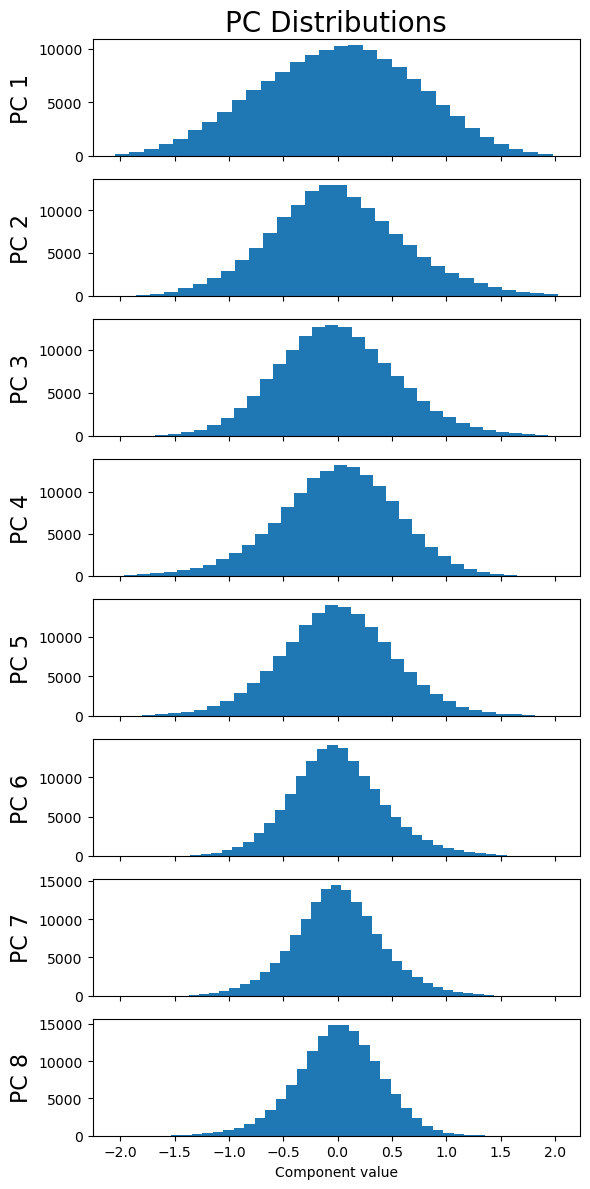

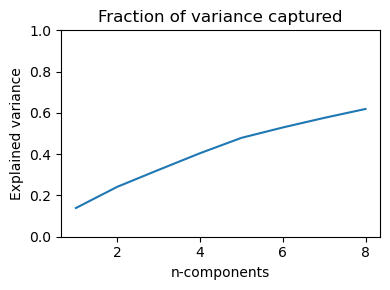

In [7]:
##################### PCA relevant figures #######################


########### plot distributions of PCs ###################
import matplotlib.pyplot as plt
fig, axes = plt.subplots(npcs, 1, figsize=(6,12), sharex=True)
for i, ax in enumerate(axes[:]):
    ax.hist(df[pc_names].iloc[:,i].values, 30)
# for i, ax in enumerate(axes[:,1]):
#     ax.hist(nuc_weights[:,i], 30, (-2,2))
    
axes[0].set_title("PC Distributions", fontsize = 20)
# axes[0,1].set_title("Nucleus Distributions", fontsize = 20)
[ax.set_ylabel("PC %i"%(i+1), fontsize = 16) for i, ax in enumerate(axes[:])];
axes[7].set_xlabel("Component value")

plt.tight_layout()
plt.savefig(datadir.joinpath('PC distributions.png'), bbox_inches='tight')



# How much variance is explained?
cell_variance = np.cumsum(pca.explained_variance_ratio_)
component_number = np.arange(len(cell_variance)) + 1

# Analysis of explained variance
df_dimred = {}
loading = pca.components_.T * np.sqrt(pca.explained_variance_)
for comp, pc_name in enumerate(pc_names):
    load = loading[:, comp]
    pc = [v for v in load]
    apc = [v for v in np.abs(load)]
    total = np.sum(apc)
    cpc = [100 * v / total for v in apc]
    df_dimred[pc_name] = pc
    df_dimred[pc_name.replace("_PC", "_aPC")] = apc
    df_dimred[pc_name.replace("_PC", "_cPC")] = cpc

# Store results as a dataframe
df_dimred["features"] = coeff_df.columns
df_dimred = pd.DataFrame(df_dimred)
df_dimred = df_dimred.set_index("features", drop=True)

# Plot variance
plt.figure(figsize=(4, 3))
plt.plot(component_number, cell_variance)
plt.ylim(0,1)
plt.xlabel("n-components")
plt.ylabel("Explained variance")
plt.title("Fraction of variance captured")

plt.tight_layout()
plt.savefig(datadir.joinpath('Variance captured.png'), bbox_inches='tight')



# ######## OR A DIFFERENT PLOT ##############
# # Make plot of explained variance
# plt.plot(100 * pca.explained_variance_ratio_[:npcs_to_calc], "-o")
# title = "Cum. variance: (1+2) = {0}%, Total = {1}%".format(
#     int(100 * pca.explained_variance_ratio_[:2].sum()),
#     int(100 * pca.explained_variance_ratio_[:].sum()),
# )
# plt.xlabel("Component", fontsize=18)
# plt.ylabel("Explained variance (%)", fontsize=18)
# plt.xticks(
#     ticks=np.arange(npcs_to_calc),
#     labels=np.arange(1, 1 + npcs_to_calc),
#     fontsize=14,
# )
# plt.yticks(fontsize=14)
# plt.title(title, fontsize=18)
# plt.tight_layout()



############## SEE WHICH FEATURES ARE MOST IMPORTANT IN EACH PC #############
save = datadir.joinpath('Feature_Importance.txt')
# Log feature importance along each PC
with open(save, "w") as flog:

    for comp in range(npcs):

        print(
            f"\nExamplined variance by PC{comp+1} = {100*pca.explained_variance_ratio_[comp]:.1f}%",
            file=flog,
        )

        # Feature importance is reported in 3 ways:
        # _PC - raw loading
        # _aPC - absolute loading
        # _cPC - normalized cummulative loading
        pc_name = pc_names[comp]
        df_sorted = df_dimred.sort_values(
            by=[pc_name.replace("_PC", "_aPC")], ascending=False
        )
        pca_cum_contrib = np.cumsum(
            df_sorted[pc_name.replace("_PC", "_aPC")].values
            / df_sorted[pc_name.replace("_PC", "_aPC")].sum()
        )
        pca_cum_thresh = np.abs(pca_cum_contrib - 0.80).argmin()
        df_sorted = df_sorted.head(n=pca_cum_thresh + 1)

        print(
            df_sorted[
                [
                    pc_name,
                    pc_name.replace("_PC", "_aPC"),
                    pc_name.replace("_PC", "_cPC"),
                ]
            ].head(),
            file=flog,
        )

In [9]:
############# CALCULATE bins for CGPS ###################
    
cgps_nbins = config.db_params.nbins


#remove the "Cell_" from PCs
for x in df.columns.to_list():
    if 'PC' in x:
        df = df.rename(columns = {x:x.replace('Cell_','')})

#list of PCs
pclist = [x for x in df.columns.to_list() if 'PC' in x and 'bins' not in x]

#bin PCs centered on zero 
center_array = np.zeros((len(pclist),cgps_nbins))
for i, pc in enumerate(pclist):
    pcvals = df[pc]
    maxval = max(pcvals.max(),abs(pcvals.min()))
    bin_edges = np.linspace(-maxval,maxval,cgps_nbins+1)
    binw = np.diff(bin_edges)[0]/2
    bin_centers = (bin_edges + binw)[:-1]
    #make extreme edges inf to avoid edge digitization errors
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    df[pc+'bins'] = np.digitize(np.round(pcvals,6), bin_edges)
    
    center_array[i] = bin_centers
centers = pd.DataFrame(center_array.T, columns = pclist)
centers.to_csv(datadir.joinpath('PC_bin_centers.csv'))
            
            
df.to_csv(datadir.joinpath('All_Data_with_CGPS_bins.csv'))
print('Calculated combined PCs and binned PCs')


Calculated combined PCs and binned PCs
